In [3]:
import sys

sys.path.append("../")

import numpy as np
from abc import ABC, abstractmethod
from typing import Union, Sequence
import os
from pathlib import Path
import sys
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from trading_information.mechanism import Mechanism
from trading_information.distributions import Uniform, BetaMixture
from trading_information.virtual_values import VirtualValues


import matplotlib.cm as cm
import matplotlib as mpl

from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

In [35]:
experiments = {
        "uniform": Uniform(0, 1),
        "gaussian": stats.norm(0, 0.3),
        "expon": stats.expon(),
        "beta_mixture": BetaMixture((8, 60), (30, 30), (0.5, 0.5)),
        "low": BetaMixture([80], [20], [1]),  # low
        "high": BetaMixture([20], [80], [1]),  # low
    }

# for uniform distribution, when postive virtual value foes above the negative one,
# we sell no information

# for beta distribution we get a similar phenomianm except part
# of the virtual value reminas positiveso we can sell some info

dist =  BetaMixture((8, 60), (30, 30), (0.5, 0.5))
#dist = Uniform(0, 1)
tau = 0
num_types = 100
types = np.linspace(0, 1, num_types)
prob_state0 = 1
taus = (0, 0.25, 0.5, 0.9, 1)
multipliers = (0.5, 0.625, 0.75, 0.95, 1)


prob_state0 = 0.5
tau = 0


virtuals = VirtualValues(dist, types, tau, prob_state0, iron=False)

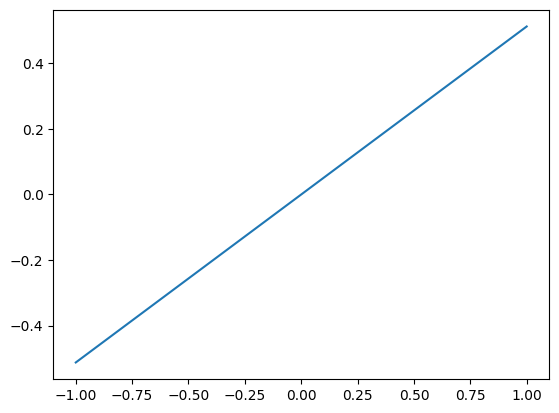

In [36]:
type = 0.5
prob_state0 = 1
alls = np.linspace(-1, 1, 100)
alpha =  tau * (1 - 2 * prob_state0)
vv = dist.pdf(type) * (type + alpha * prob_state0) + dist.cdf(type)

plt.plot(alls, vv * alls)

In [37]:
def externality_for_type(type, x):
    ps1 = 1 - prob_state0 - prob_state0 * x + (1 - 2 * prob_state0) * np.minimum(0, -x)
    externality = ps1
    externality *= 1 - 2 * prob_state0
    # externality *= prob_state0
    externality *= tau

    return externality + tau * prob_state0

In [40]:
type = 0
allocation = np.linspace(-1, 1, 100)

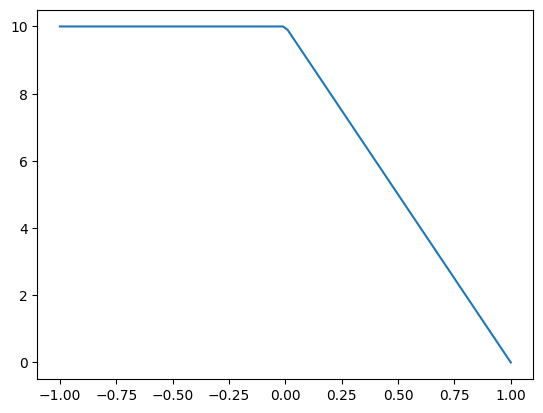

In [52]:
type = 0
prob_state0 = 0
tau = 10

plt.plot(allocation, externality_for_type(type, allocation))